Based on bad_fibers-fugu.ipynb

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

345431


In [4]:
cat['MEAN_X'], cat['MEAN_Y'] = 0., 0.
for fiber in np.unique(cat['FIBER']):
    mask = cat['FIBER']==fiber
    cat['MEAN_X'][mask] = np.mean(cat['FIBERASSIGN_X'][mask])
    cat['MEAN_Y'][mask] = np.mean(cat['FIBERASSIGN_Y'][mask])

In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
cat['q'] = ((cat['DELTACHI2']>d) & (cat['DELTACHI2']>10)) | (cat['DELTACHI2']>30)
cat['q'] &= cat['Z']<1.4
cat['q'] &= cat['ZWARN']<1.4
print(np.sum(~cat['q'])/len(cat))

# mask = cat['EBV']<0.1
# print(np.sum(mask)/len(mask))
# cat = cat[mask]
# print(len(cat))

FIBERSTATUS    7165 338266 0.020742203218587794
No data    1 338265 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
Min depth    11352 288287 0.037885588992087146
0.011276956643900002


In [6]:
# # WISE and MEDIUM masks
# maskbits = [8, 9, 11]
# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
# cat = cat[mask_clean]

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [8]:
mask_gal = cat['SPECTYPE']=='GALAXY'
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
mask_qso = cat['SPECTYPE']=='QSO'

# Force the very low-z objects to have SPECTYPE=STAR
cat['SPECTYPE'][mask_star] = 'STAR'

In [9]:
cat['Z'][mask_gal].max()

1.6997381804123994

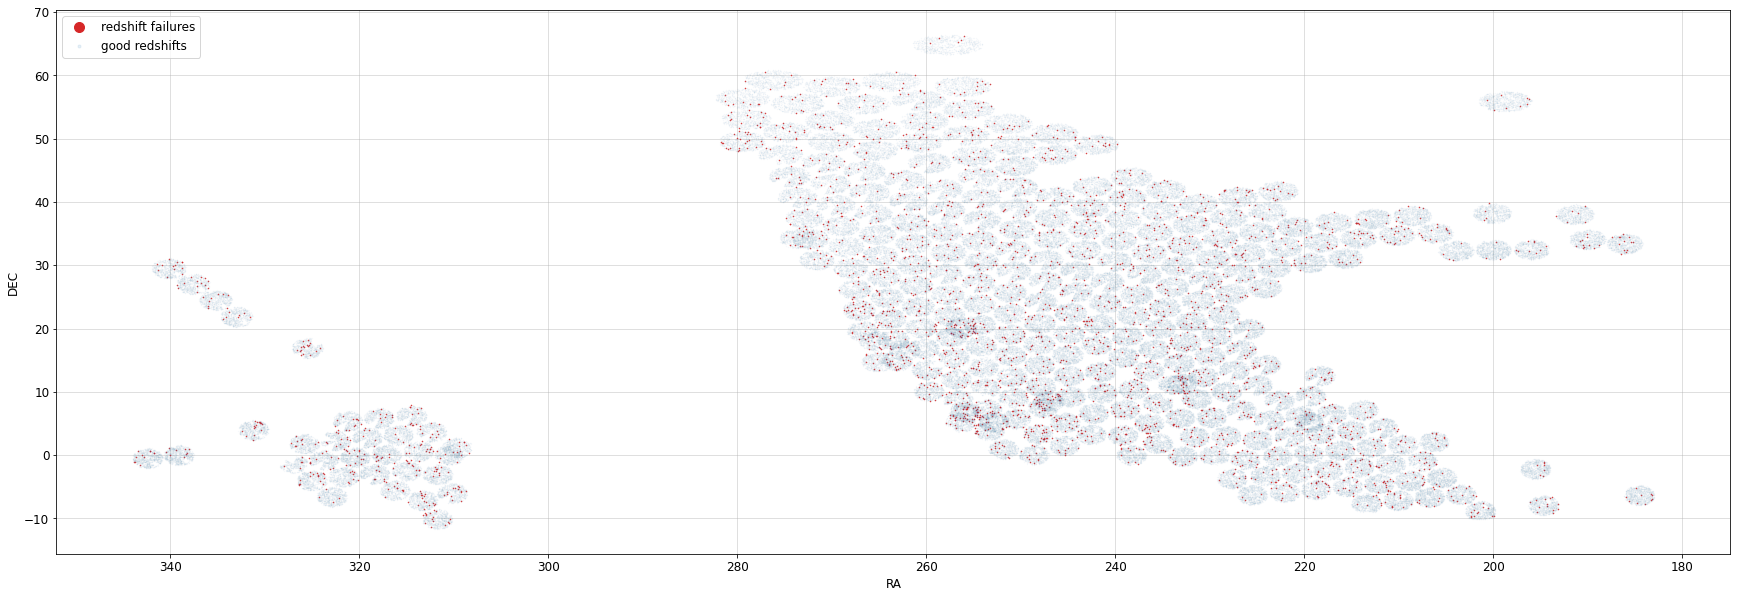

In [10]:
plt.figure(figsize=(30, 10))
plt.plot(cat['TARGET_RA'][~cat['q']], cat['TARGET_DEC'][~cat['q']], 'C3.', ms=1, label='redshift failures')
plt.plot(cat['TARGET_RA'][cat['q']], cat['TARGET_DEC'][cat['q']], 'C0.', ms=.3, alpha=0.1, label='good redshifts')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper left', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

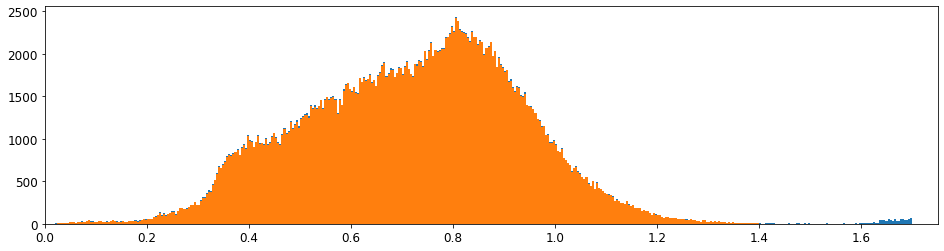

In [11]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=False, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & cat['q']], 500, log=False, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

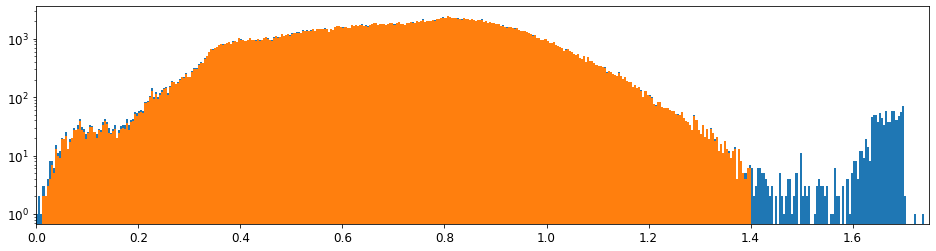

In [12]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=True, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & cat['q']], 500, log=True, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

In [13]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats.sort('n_tot')

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~cat['q']], return_counts=True)
fiberstats = join(fiberstats, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats['frac_fail'] = fiberstats['n_fail']/fiberstats['n_tot']

error_floor = True

n, p = fiberstats['n_tot'].copy(), fiberstats['frac_fail'].copy()
if error_floor:
    p1 = np.maximum(p, 1/n)  # error floor
else:
    p1 = p
fiberstats['frac_fail_err'] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
fiberstats.sort('n_fail')

fiberstats

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
4170,67,0,0.0,0.014813571012293428
4081,67,0,0.0,0.014813571012293428
4082,73,0,0.0,0.01360448036058687
4083,69,0,0.0,0.014387350379788876
2713,69,0,0.0,0.014387350379788876
4085,72,0,0.0,0.013792101027561326
2714,70,0,0.0,0.014183306411342087
3314,64,0,0.0,0.015502449088269086
4088,74,0,0.0,0.013421895416371774


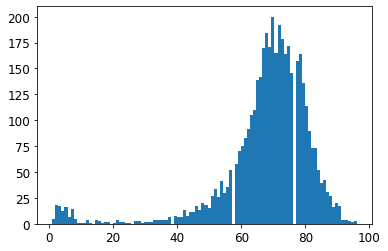

In [14]:
plt.hist(fiberstats['n_tot'], 100);

In [15]:
fiberstats['MEAN_X'], fiberstats['MEAN_Y'] = 0., 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    mask = cat['FIBER']==fiber
    fiberstats['MEAN_X'][index], fiberstats['MEAN_Y'][index] = cat['MEAN_X'][mask][0], cat['MEAN_Y'][mask][0]

In [16]:
print(len(fiberstats))
mask = fiberstats['n_tot']>40
print(np.sum(mask))
print(np.median(fiberstats['n_tot'][mask]))

4242
4062
71.0


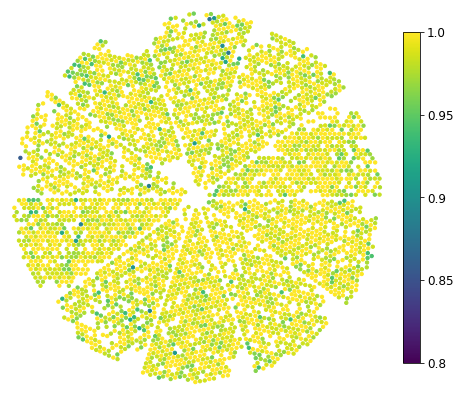

In [17]:
mask = fiberstats['n_tot']>40

fig, ax = plt.subplots(figsize=(6.5, 5.6))
cax = ax.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=11, vmin=0.8, vmax=1., cmap='viridis')
ax.axis([-420, 420, -420, 420])
# plt.colorbar(fraction=0.04, pad=0.04)
cbar = fig.colorbar(cax, ticks=[0.80, 0.85, 0.90, 0.95, 1.0], fraction=0.04, pad=0.04)
cbar.ax.set_yticklabels([0.80, 0.85, 0.90, 0.95, 1.0])  # horizontal colorbar
plt.axis('off')
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/fiber_to_fiber.pdf')
plt.show()

In [18]:
median_efftime = Table()
median_efftime['FIBER'] = np.unique(cat['FIBER'])
median_efftime['EFFTIME_LRG'] = np.nan
for index in range(len(median_efftime)):
    fiber = median_efftime['FIBER'][index]
    mask = cat['FIBER']==fiber
    median_efftime['EFFTIME_LRG'][index] = np.median(cat['EFFTIME_LRG'][mask])

fiberstats = join(fiberstats, median_efftime, keys='FIBER')

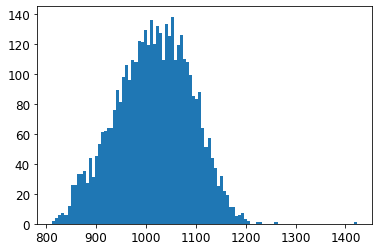

In [19]:
plt.hist(fiberstats['EFFTIME_LRG'], 100);

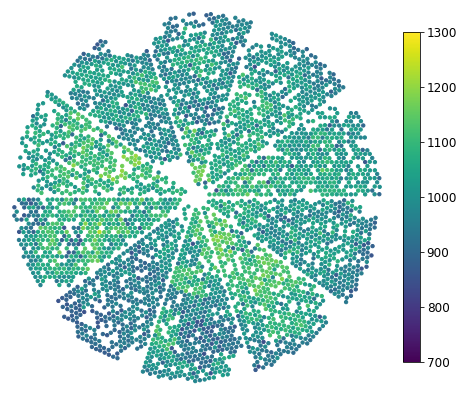

In [20]:
mask = fiberstats['n_tot']>40

fig, ax = plt.subplots(figsize=(6.55, 5.6))
cax = ax.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=fiberstats['EFFTIME_LRG'][mask],
            s=11, vmin=700, vmax=1300, cmap='viridis')
ax.axis([-420, 420, -420, 420])
fig.colorbar(cax, fraction=0.04, pad=0.04)
plt.axis('off')
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/fiber_to_fiber.pdf')
plt.show()

In [21]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

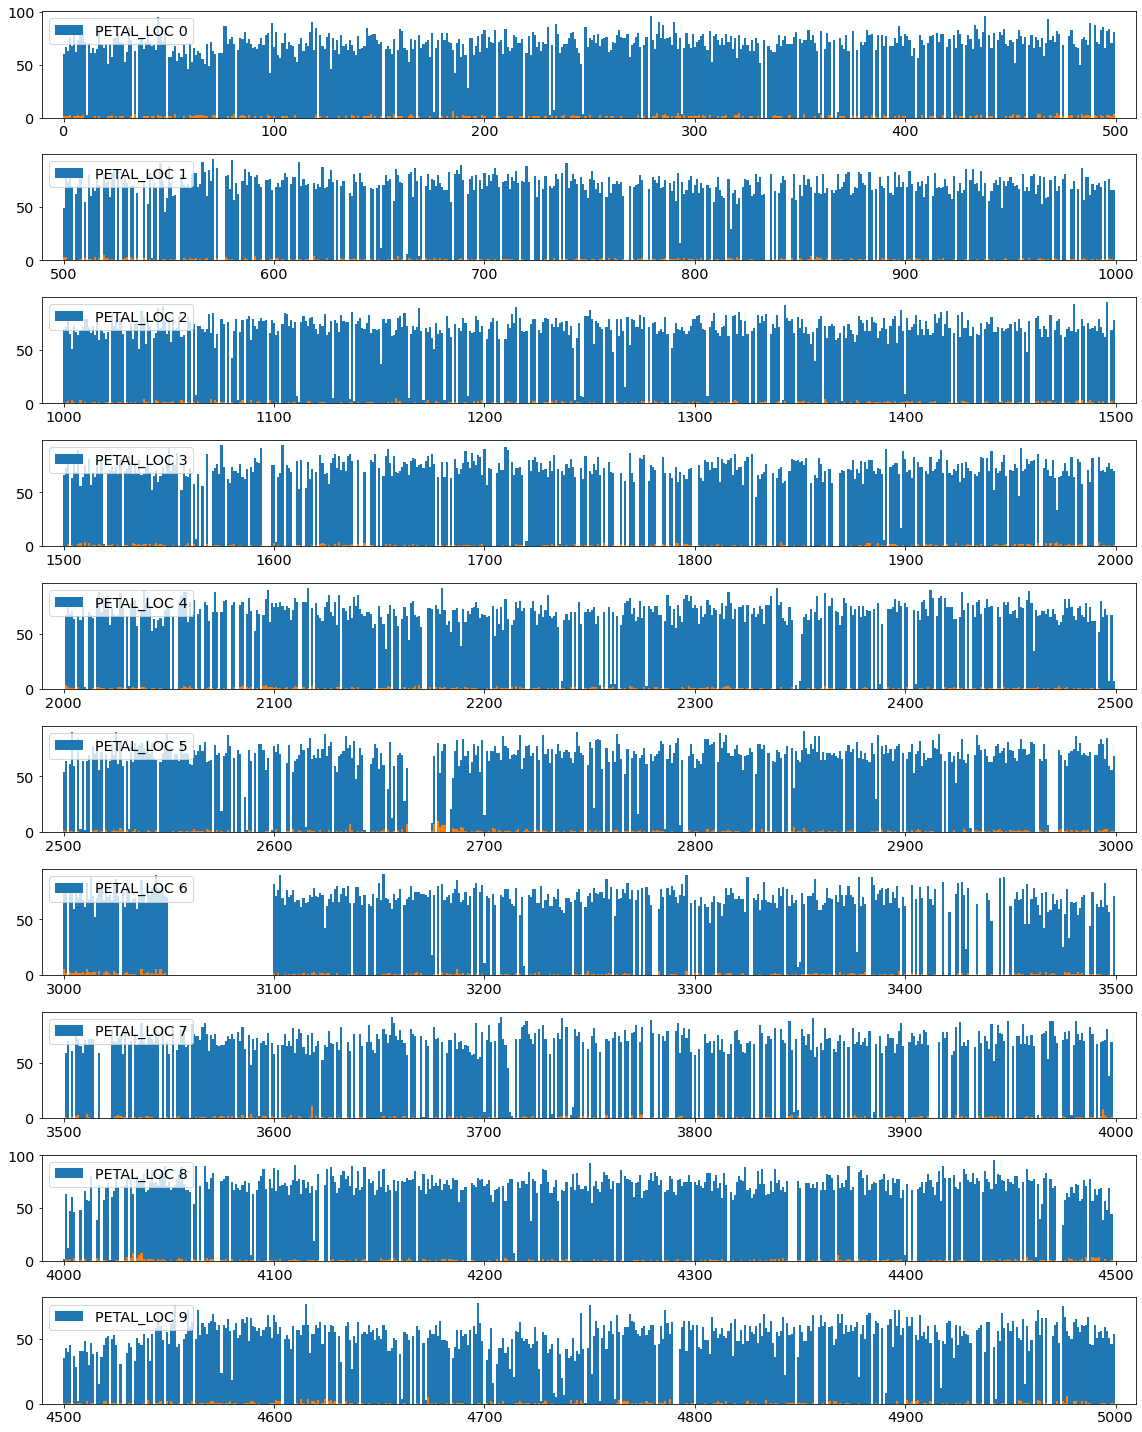

In [22]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~cat['q'])], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [23]:
frac_fail_threshold = 0.1

mask_threshold = fiberstats['frac_fail']>=frac_fail_threshold
print(np.sum(mask_threshold), np.sum(mask_threshold)/len(mask_threshold))
print(np.mean(fiberstats['frac_fail'][mask_threshold]), np.mean(fiberstats['frac_fail']), np.mean(fiberstats['frac_fail'][~mask_threshold]))
print(np.sum(fiberstats['n_fail'][mask_threshold])/np.sum(fiberstats['n_fail']))

bad_fibers = fiberstats['FIBER'][mask_threshold].copy()
print(len(bad_fibers))

17 0.004007543611504008
0.1675308189536802 0.011669759466356988 0.011042626209248233
0.022762227007074746
17


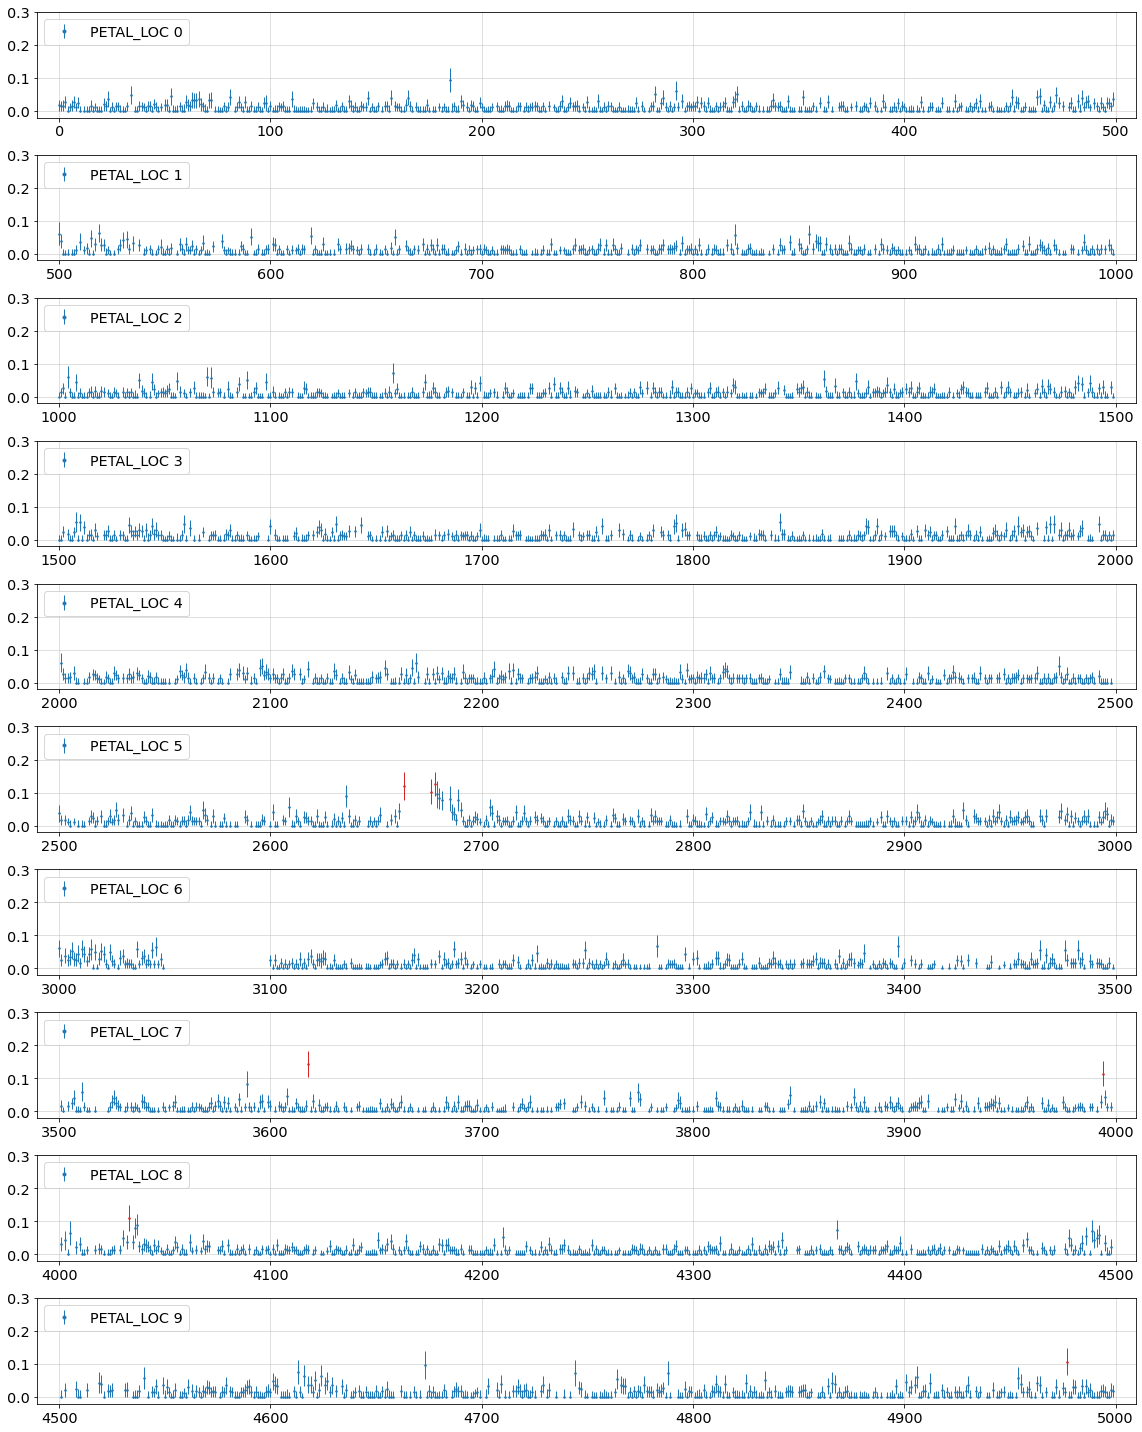

In [24]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (fiberstats['FIBER']>fiber_min) & (fiberstats['FIBER']<fiber_max)
    mask &= (fiberstats['n_tot']>40)
    mask_good = mask & (~np.in1d(fiberstats['FIBER'], bad_fibers))
    mask_bad = mask & np.in1d(fiberstats['FIBER'], bad_fibers)
    # plt.figure(figsize=(16, 2))
    ax[index].errorbar(fiberstats['FIBER'][mask_good], fiberstats['frac_fail'][mask_good], 
                       yerr=(np.clip(fiberstats['frac_fail_err'][mask_good], None, fiberstats['frac_fail'][mask_good]), fiberstats['frac_fail_err'][mask_good]),
                       color='C0', fmt='.', ms=3, elinewidth=1, label='PETAL_LOC {}'.format(index))
    ax[index].errorbar(fiberstats['FIBER'][mask_bad], fiberstats['frac_fail'][mask_bad],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad], None, fiberstats['frac_fail'][mask_bad]), fiberstats['frac_fail_err'][mask_bad]),
                   color='C3', fmt='.', ms=3, elinewidth=1)
    ax[index].grid(alpha=0.5)
    ax[index].set_yticks([0., 0.1, 0.2, 0.3], minor=False)
    ax[index].set_ylim(-0.02, 0.3)
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [25]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

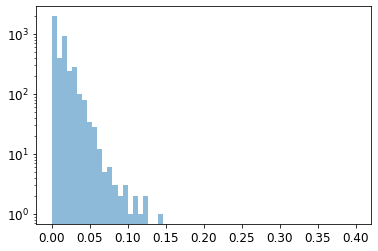

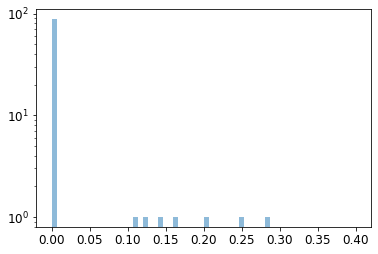

In [26]:
mask = fiberstats['n_tot']>40
plt.hist(fiberstats['frac_fail'][mask], 60, range=(0, 0.4), log=True, alpha=0.5)
plt.show()

mask = fiberstats['n_tot']<=10
plt.hist(fiberstats['frac_fail'][mask], 60, range=(0, 0.4), log=True, alpha=0.5)
plt.show()

---------
## Predict the redshift failures

Based on predicting_redshifts_failure_rates.ipynb

In [27]:
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['qf'] = np.array(cat['q'], dtype=float)

In [28]:
def failure_rate(flux, efftime, a, b, c):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(-(sn+a)/b)+c/flux, 0, 1)

# From Main LRGs + SV3 LRGs + Main LRGs from SV1; EBV<0.1
params = [-3.25288364e+01,  1.11713253e+01,  2.92794005e-02]

In [29]:
cat['success_prob'] = 1-failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *params)
print(np.sum(~cat['q']), np.sum(1-cat['success_prob']))
print(np.sum(~cat['q'])/np.sum(1-cat['success_prob']))

3251 3334.7703
0.9748797497133621


In [30]:
# fiberstats['n_fail_predict'] = 0.
# fiberstats['frac_fail_predict'] = 0.
# for index, fiber in enumerate(fiberstats['FIBER']):
#     mask = cat['FIBER']==fiber
#     fiberstats['n_fail_predict'][index] = np.sum(1-cat['success_prob'][mask])
#     fiberstats['frac_fail_predict'][index] = fiberstats['n_fail_predict'][index]/fiberstats['n_tot'][index]
    
# mask = fiberstats['n_tot']>40

# fig, ax = plt.subplots(figsize=(6.5, 5.6))
# cax = ax.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail_predict'][mask],
#             s=11, vmin=0.8, vmax=1., cmap='viridis')
# ax.axis([-420, 420, -420, 420])
# # plt.colorbar(fraction=0.04, pad=0.04)
# cbar = fig.colorbar(cax, ticks=[0.80, 0.85, 0.90, 0.95, 1.0], fraction=0.04, pad=0.04)
# cbar.ax.set_yticklabels([0.80, 0.85, 0.90, 0.95, 1.0])  # horizontal colorbar
# plt.axis('off')
# plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/fiber_to_fiber_predict.pdf')
# plt.show()

In [31]:
np.random.seed(9999999)
rand = np.random.rand(len(cat))
q_sim = rand<cat['success_prob']

fiberstats_sim = fiberstats.copy()[['FIBER', 'n_tot', 'MEAN_X', 'MEAN_Y']]

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~q_sim], return_counts=True)
fiberstats_sim = join(fiberstats_sim, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats_sim['frac_fail'] = fiberstats_sim['n_fail']/fiberstats_sim['n_tot']

fiberstats_sim

FIBER,n_tot,MEAN_X,MEAN_Y,n_fail,frac_fail
int32,int64,float64,float64,int64,float64
0,60,83.45533752441406,-286.920166015625,2,0.03333333333333333
1,67,58.726016998291016,-272.7911376953125,2,0.029850746268656716
2,63,31.71273422241211,-269.9549865722656,0,0.0
3,75,0.2868148386478424,-220.76048278808594,2,0.02666666666666667
4,68,-19.89693832397461,-252.5083465576172,1,0.014705882352941176
5,80,41.23762512207031,-239.81967163085938,1,0.0125
6,62,14.3618745803833,-264.7234802246094,0,0.0
7,73,17.58331871032715,-227.08631896972656,0,0.0
8,81,73.07315826416016,-289.4292907714844,1,0.012345679012345678


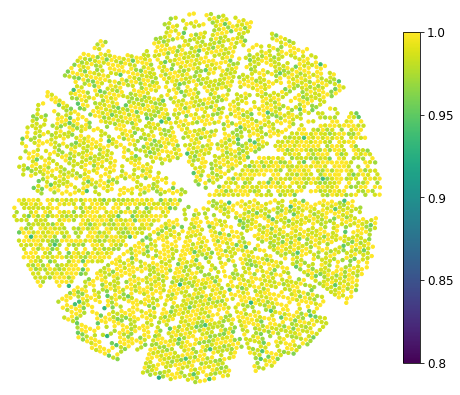

In [32]:
mask = fiberstats_sim['n_tot']>40

fig, ax = plt.subplots(figsize=(6.5, 5.6))
cax = ax.scatter(fiberstats_sim['MEAN_X'][mask], fiberstats_sim['MEAN_Y'][mask], c=1-fiberstats_sim['frac_fail'][mask],
            s=11, vmin=0.8, vmax=1., cmap='viridis')
ax.axis([-420, 420, -420, 420])
# plt.colorbar(fraction=0.04, pad=0.04)
cbar = fig.colorbar(cax, ticks=[0.80, 0.85, 0.90, 0.95, 1.0], fraction=0.04, pad=0.04)
cbar.ax.set_yticklabels([0.80, 0.85, 0.90, 0.95, 1.0])  # horizontal colorbar
plt.axis('off')
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/more/fiber_to_fiber_sim.pdf')
plt.show()

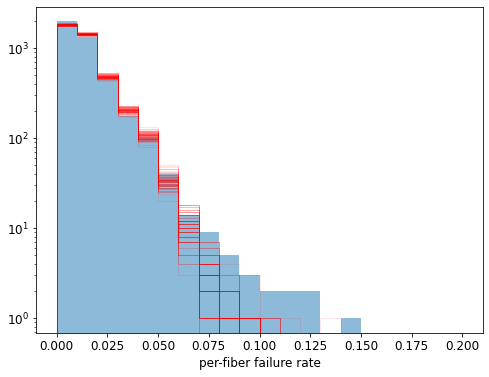

In [33]:
plt.figure(figsize=(8, 6))
mask = fiberstats['n_tot']>40
plt.hist(fiberstats['frac_fail'][mask], 20, range=(0, 0.2), log=True, alpha=0.5)

nsims = 100
np.random.seed(9999999)
for index in range(nsims):
    rand = np.random.rand(len(cat))
    q_sim = rand<cat['success_prob']
    fiberstats_sim = fiberstats.copy()[['FIBER', 'n_tot', 'MEAN_X', 'MEAN_Y']]
    tt = Table()
    tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~q_sim], return_counts=True)
    fiberstats_sim = join(fiberstats_sim, tt, keys='FIBER', join_type='outer').filled(0)
    fiberstats_sim['frac_fail'] = fiberstats_sim['n_fail']/fiberstats_sim['n_tot']
    mask = fiberstats_sim['n_tot']>40
    plt.hist(fiberstats_sim['frac_fail'][mask], 20, range=(0, 0.2), log=True, alpha=0.1, histtype='step', color='r')

plt.xlabel('per-fiber failure rate')
plt.show()